# makemore: part 3

Activations, gradients, initialization, and BatchNorm.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

# Keep the lecture code direct; only place the expensive tensor work on GPU when available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X).to(device)
  Y = torch.tensor(Y).to(device)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## MLP revisited

Start with the MLP from part 2 and inspect what is wrong with it at initialization.

In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden,                        generator=g).to(device)
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device)
b2 = torch.randn(vocab_size,                      generator=g).to(device)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 27.8817


  10000/ 200000: 2.7716


  20000/ 200000: 2.5500


  30000/ 200000: 2.8352


  40000/ 200000: 2.0948


...

 150000/ 200000: 2.1858


 160000/ 200000: 2.0545


 170000/ 200000: 1.8764


 180000/ 200000: 2.0119


 190000/ 200000: 1.8302


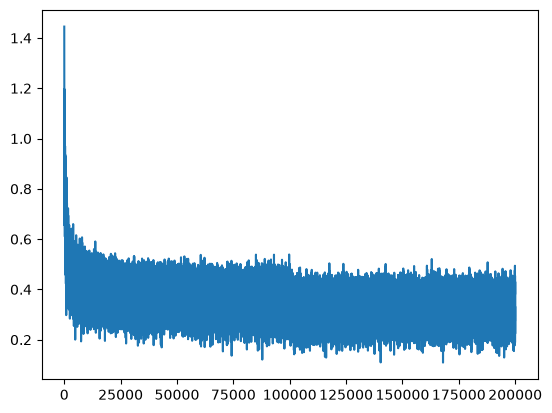

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1228504180908203
val 2.1652700901031494


In [10]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context], device=device)] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1).cpu()
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).to(device).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
amille.
khirmre.
reyty.
skanden.
jazhube.
den.
arci.
aqui.
ner.
kentzieiivon.
leigh.
ham.
jorn.
quinn.
salin.
alianni.
wanell.
dearynix.
kaellissa.


## Fixing the initial loss

At initialization there is no reason to prefer any of the 27 characters. A uniform distribution should therefore give a loss of $-\log(1/27) = \log(27)$.

In [11]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [12]:
# four-dimensional example of the problem
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([ -2.4341, -13.3007,  -6.0277,  -7.3322]),
 tensor([9.6620e-01, 1.8441e-05, 2.6570e-02, 7.2091e-03]),
 tensor(3.6280))

In [13]:
# reinitialize the network and inspect only the first iteration
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden,                        generator=g).to(device)
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device)
b2 = torch.randn(vocab_size,                      generator=g).to(device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g).to(device)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())
logits[0]

27.881732940673828


tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [14]:
# make the output layer less confidently wrong at initialization
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden,                        generator=g).to(device)
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
b2 = torch.randn(vocab_size,                      generator=g).to(device) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g).to(device)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())
logits[0]

3.32205867767334


tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
         0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
        -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
        -0.2154,  0.0725,  0.1141], device='cuda:0', grad_fn=<SelectBackward0>)

In [15]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2991


  10000/ 200000: 1.8699


  20000/ 200000: 1.9217


  30000/ 200000: 2.0586


  40000/ 200000: 2.2060


...

 150000/ 200000: 2.4514


 160000/ 200000: 2.2409


 170000/ 200000: 1.7868


 180000/ 200000: 1.9175


 190000/ 200000: 2.1603


train 2.0694077014923096
val 2.1312122344970703


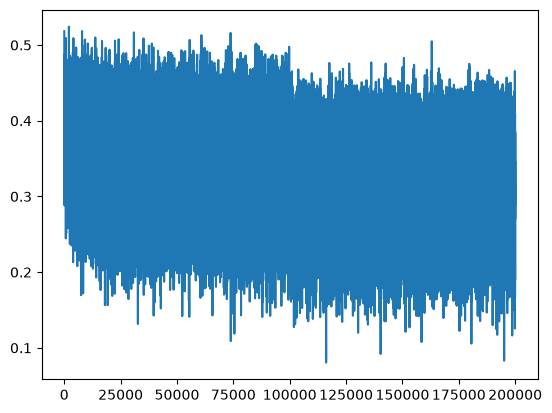

In [16]:
plt.plot(lossi)
split_loss('train')
split_loss('val')

## Fixing the saturated `tanh`

The initial loss is now sensible, but a good scalar loss can hide unhealthy internal activations. Reinitialize and inspect `h` and `hpreact` on the first batch.

In [17]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden,                        generator=g).to(device)
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
b2 = torch.randn(vocab_size,                      generator=g).to(device) * 0

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g).to(device)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
loss

tensor(3.3221, device='cuda:0')

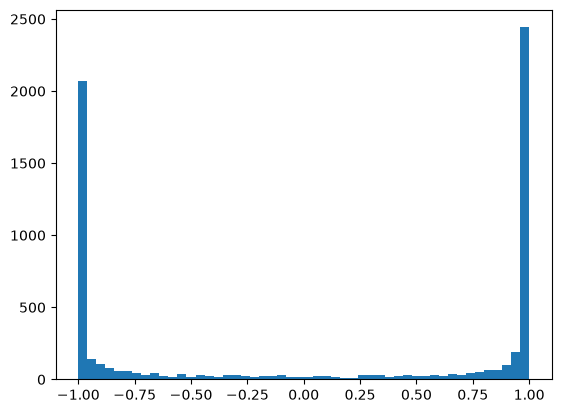

In [18]:
plt.hist(h.view(-1).detach().cpu().tolist(), 50);

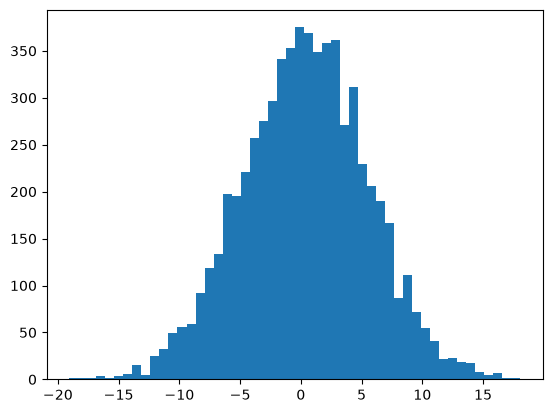

In [19]:
plt.hist(hpreact.view(-1).detach().cpu().tolist(), 50);

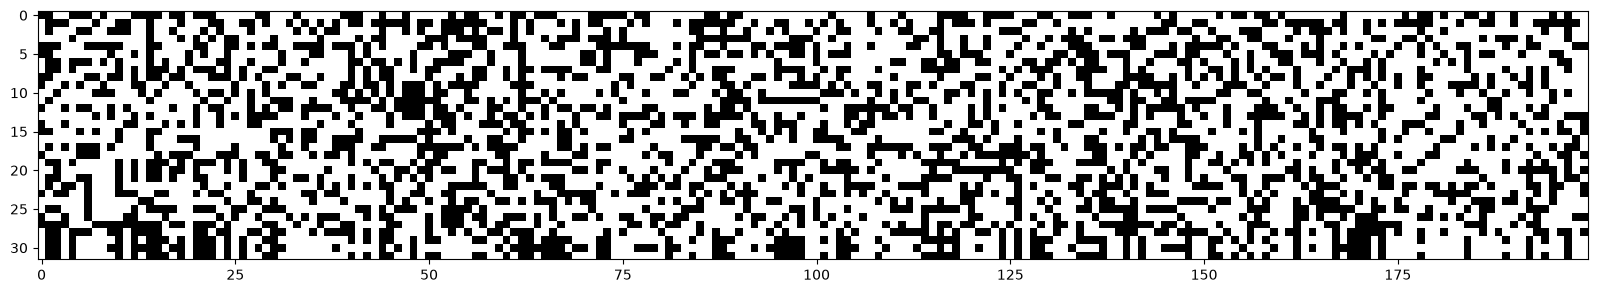

In [20]:
# white marks a saturated tanh activation for one example and one hidden neuron
plt.figure(figsize=(20, 10))
plt.imshow((h.abs() > 0.99).detach().cpu(), cmap='gray', interpolation='nearest');

For `tanh`, the local derivative is $1-t^2$. Values near -1 or 1 almost stop the gradient. A neuron is dead only if its entire column is white: it is saturated for every example in the batch.

In [21]:
# if h is ±1, the gradient through tanh is destroyed; keep it in the active region
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device) * 0.2
b1 = torch.randn(n_hidden,                        generator=g).to(device) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
b2 = torch.randn(vocab_size,                      generator=g).to(device) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [22]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3135


  10000/ 200000: 2.1648


  20000/ 200000: 2.3061


  30000/ 200000: 2.4541


  40000/ 200000: 1.9787


...

 150000/ 200000: 2.1948


 160000/ 200000: 1.8619


 170000/ 200000: 1.7809


 180000/ 200000: 1.9673


 190000/ 200000: 1.8295


train 2.0355966091156006
val 2.1026782989501953


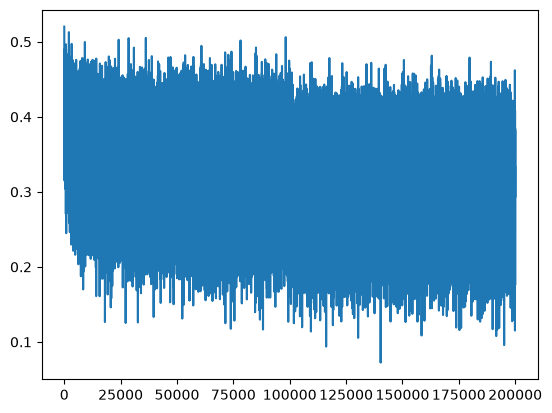

In [23]:
plt.plot(lossi)
split_loss('train')
split_loss('val')

## Semi-principled initialization

The factor `0.2` works, but it is a magic number. Derive the scale from the number of inputs instead.

tensor(0.0293) tensor(0.9896)
tensor(0.0110) tensor(3.1141)


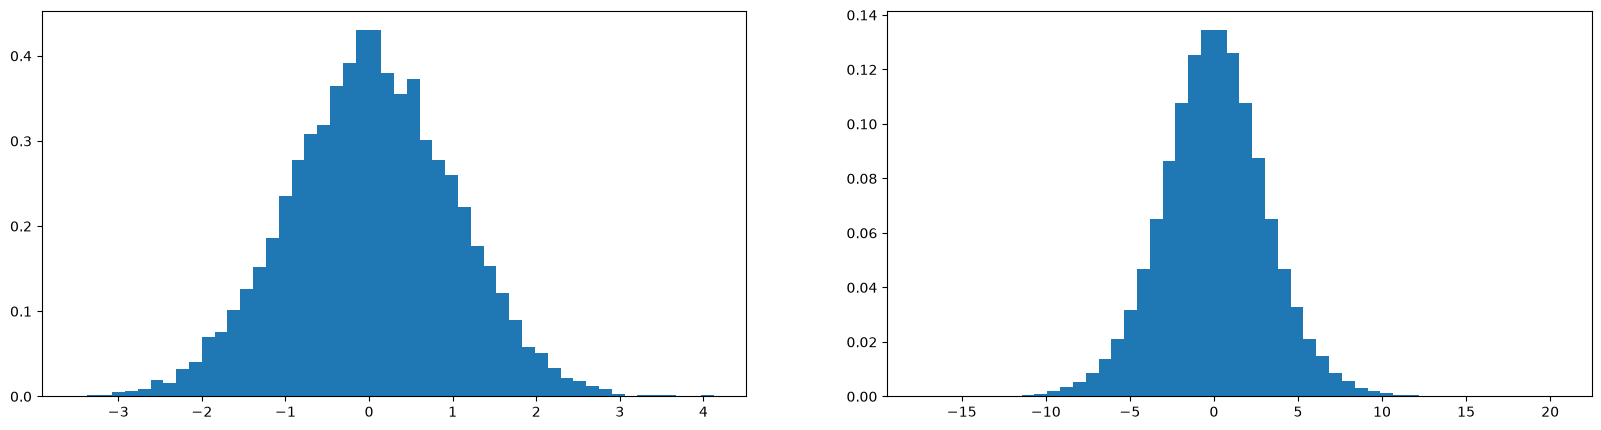

In [24]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [25]:
# scaling by 1/sqrt(fan_in) preserves the variance of a linear layer
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

tensor(-0.0034) tensor(1.0002)
tensor(0.0052) tensor(1.0135)


In [26]:
torch.nn.init.calculate_gain('tanh')

1.6666666666666667

In [27]:
# use Kaiming initialization for tanh instead of the magic 0.2
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g).to(device) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
b2 = torch.randn(vocab_size,                      generator=g).to(device) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [28]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3179


  10000/ 200000: 2.1910


  20000/ 200000: 2.3270


  30000/ 200000: 2.5396


  40000/ 200000: 1.9468


...

 150000/ 200000: 2.1458


 160000/ 200000: 1.7824


 170000/ 200000: 1.7249


 180000/ 200000: 1.9752


 190000/ 200000: 1.8614


train 2.0376644134521484
val 2.106989622116089


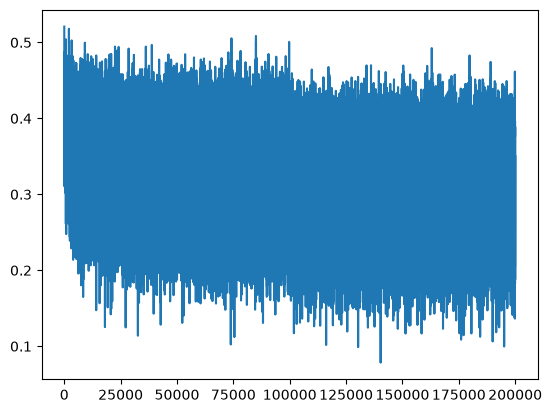

In [29]:
plt.plot(lossi)
split_loss('train')
split_loss('val')

## Batch normalization

Instead of balancing a pencil on your finger at every layer, normalize every hidden unit over the current mini-batch, then restore a learnable scale and shift with `bngain` and `bnbias`.

In [30]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g).to(device)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g).to(device) * (5/3) / (n_embd * block_size)**0.5
W2 = torch.randn((n_hidden, vocab_size),          generator=g).to(device) * 0.01
b2 = torch.randn(vocab_size,                      generator=g).to(device) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden), device=device)
bnbias = torch.zeros((1, n_hidden), device=device)

# buffers, updated with a running momentum update
bnmean_running = torch.zeros((1, n_hidden), device=device)
bnstd_running = torch.ones((1, n_hidden), device=device)

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12097


In [31]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g).to(device)
  Xb, Yb = Xtr[ix], Ytr[ix]

  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  # Linear layer
  hpreact = embcat @ W1
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3239


  10000/ 200000: 2.0322


  20000/ 200000: 2.5675


  30000/ 200000: 2.0125


  40000/ 200000: 2.2446


...

 150000/ 200000: 2.0027


 160000/ 200000: 2.0997


 170000/ 200000: 2.4949


 180000/ 200000: 2.0199


 190000/ 200000: 2.1707


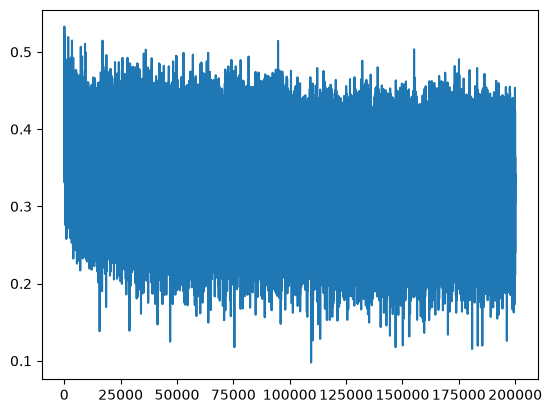

In [32]:
plt.plot(lossi)

In [33]:
# calibrate the batch norm at the end of training
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

print('mean difference:', (bnmean - bnmean_running).abs().mean().item())
print('std difference: ', (bnstd - bnstd_running).abs().mean().item())

mean difference: 0.007905475795269012
std difference:  0.022672681137919426


In [34]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674149990081787
val 2.1056838035583496


The bias before BatchNorm is useless: subtracting the batch mean cancels it. During training, the batch statistics couple the examples and inject noise; during inference, fixed running statistics make single-example predictions possible.

### loss log

- original: train 2.1245, val 2.1682
- fix softmax confidently wrong: train ~2.07, val ~2.13
- fix saturated `tanh`: train 2.0356, val 2.1027
- Kaiming-style initialization: train 2.0377, val 2.1070
- add BatchNorm: train 2.0668, val 2.1048

## loss log

### original
train 2.1245384216308594  
val 2.168196439743042

### fix softmax confidently wrong
train ~2.07  
val ~2.13

### fix tanh layer too saturated at init
train 2.0355966091156006  
val 2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init
train 2.0376641750335693  
val 2.106989622116089

### add batch norm layer
train 2.0668270587921143  
val 2.104844808578491
